# Phase 9 (Part A) — Model Evaluation: the 24h Benchmark
### Energy Demand Forecasting Project

**Question this phase answers:** now that five forecasting approaches
(daily seasonal naive, SARIMA, Prophet, LightGBM, LSTM) have each been
backtested on the exact same rolling-origin, 24h-ahead setup, which one
actually wins -- and how confident can we be in that ranking?

No new models are fit here. Every analysis in this notebook re-examines
the long-format (origin, horizon_step, method, actual, forecast) results
Phases 5-8 already saved via `src/evaluation/results_store.py`, from a few
different angles that a single aggregate MAE table can't show on its own:

1. **Aggregate metrics** -- the headline MAE/RMSE/MAPE/sMAPE table, all
   methods together for the first time.
2. **Error vs. horizon step** -- all five methods on one chart.
3. **Time-series cross-validation** -- does the ranking found on the whole
   test period hold up across independent chunks of it, or is it an
   artifact of averaging over the full window?
4. **Diebold-Mariano tests** -- is each pairwise gap (especially the close
   LightGBM-vs-LSTM one) statistically meaningful, or within noise?
5. **Error by season** -- does the ranking change between winter and
   summer?
6. **Failure case analysis** -- do the worst individual predictions cluster
   around the Phase 1 data gaps or Phase 3 flagged anomaly days?

Part B (horizon sensitivity at 1h/7d) is a separate notebook, since it
requires re-running models at new horizons rather than re-analyzing what's
already saved.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation.splits import get_train_test_split
from src.evaluation.baselines import get_forecast_origins, compute_metrics, HORIZON
from src.evaluation.results_store import load_results
from src.evaluation.comparison import (
    add_season,
    assign_cv_folds,
    pairwise_dm_tests,
    worst_cases,
)
from src.features.build_features import FLAGGED_ANOMALY_DATES

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

# The five methods used consistently across Phases 5-8. Everything past the
# aggregate metrics table below focuses on these; `arima`, `naive`, and
# `weekly_seasonal_naive` were already superseded in their own phases
# (Phase 5 picked daily over weekly seasonal naive; Phase 6 picked SARIMA
# over plain ARIMA) and are shown once for completeness, then dropped.
CANONICAL_METHODS = ["daily_seasonal_naive", "sarima", "prophet", "lightgbm", "lstm"]

## Load every saved backtest result

Canonical forecast origins are recomputed (not refit -- just the same
deterministic split/origin logic every phase has used) so the CV-fold
boundaries below are defined on the full origin grid, not on whichever
subset of origins a given method happens to cover.

In [3]:
baselines = load_results("baselines")
sarima_arima = load_results("sarima_arima")
prophet_results = load_results("prophet")
lightgbm_results = load_results("lightgbm_direct")
lstm_results = load_results("lstm")

all_results = pd.concat(
    [baselines, sarima_arima, prophet_results, lightgbm_results, lstm_results],
    ignore_index=True,
)
canonical_results = all_results[all_results["method"].isin(CANONICAL_METHODS)].copy()

con = duckdb.connect("../data/energy.duckdb", read_only=True)
hourly = con.execute("SELECT datetime, global_active_power FROM hourly ORDER BY datetime").df()
con.close()
hourly["datetime"] = pd.to_datetime(hourly["datetime"])
series = hourly.set_index("datetime")["global_active_power"].asfreq("h")

test_start = get_train_test_split(series, test_frac=0.2)
canonical_origins = get_forecast_origins(series, test_start, horizon=HORIZON)

print(f"All methods loaded: {sorted(all_results['method'].unique())}")
print(f"Canonical origins: {len(canonical_origins)} ({canonical_origins.min().date()} to {canonical_origins.max().date()})")

All methods loaded: ['arima', 'daily_seasonal_naive', 'lightgbm', 'lstm', 'naive', 'prophet', 'sarima', 'weekly_seasonal_naive']
Canonical origins: 288 (2010-02-11 to 2010-11-25)


## Aggregate metrics -- every method, together for the first time

**Note on `n` before reading this table:** it isn't the same for every
method, and that's expected, not a bug. Every method is evaluated on up to
6,912 (origin, horizon_step) pairs (288 origins x 24 steps), but
`compute_metrics` drops a row wherever `actual` or `forecast` is NaN --
applied identically everywhere, but different methods lose different
amounts because of *why* a value goes missing:

- **SARIMA, Prophet, ARIMA (n=6,682):** their model-based forecasts are
  never NaN themselves, so they only lose the 230 pairs where the future
  `actual` itself falls in a Phase 1 data gap -- the shared floor every
  method is subject to.
- **naive, daily/weekly seasonal naive (n=6,660 / 6,610 / 6,452):** pure
  lookups, so on top of that same 230-row floor, their *forecast* can also
  independently be NaN whenever the value they're looking up (last known
  value, or 24h/168h back) itself lands in a gap -- a second, separate
  source of missingness. `weekly_seasonal_naive` loses the most of the
  three because its 168h lookback reaches into different, largely
  non-overlapping gap windows than the ones affecting `actual`.
- **LightGBM (n=6,156), LSTM (n=6,504):** lose the most, for a third
  reason -- their backtests require a NaN-free *feature window* before each
  origin (LightGBM's rolling features look back up to 168h; LSTM's tuned
  lookback is 48h), so any origin within that many hours of a gap is
  dropped too, not just the point values a naive lookup would touch. This
  was flagged as each model's own coverage caveat back in Phases 7-8; it's
  repeated here because this is the first table where every method's `n`
  sits side by side and the gap becomes visible at a glance.

In [4]:
summary = {
    method: compute_metrics(all_results[all_results["method"] == method])
    for method in all_results["method"].unique()
}
summary_df = pd.DataFrame(summary).T.sort_values("MAE")
summary_df

,MAE,RMSE,MAPE,sMAPE,n
lightgbm,0.428662,0.591301,61.970836,44.004024,6156.0
lstm,0.440362,0.605057,58.681965,45.621295,6504.0
prophet,0.484764,0.636522,72.701305,54.656667,6682.0
daily_seasonal_naive,0.530485,0.786247,67.304578,49.468223,6610.0
sarima,0.560217,0.775760,72.068192,57.460365,6682.0
weekly_seasonal_naive,0.562799,0.813475,76.668610,53.661401,6452.0
arima,0.631232,0.871298,72.616638,62.950308,6682.0
naive,0.663600,0.936635,68.720501,67.364054,6660.0


## Error vs. horizon step -- all five canonical methods

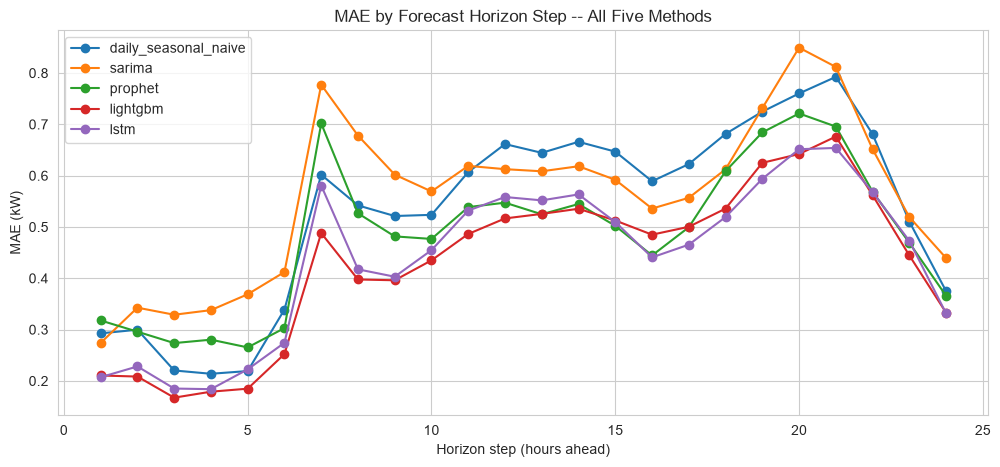

In [5]:
horizon_metrics = (
    canonical_results.groupby(["method", "horizon_step"])
    .apply(lambda d: pd.Series(compute_metrics(d)), include_groups=False)
    .reset_index()
)

fig, ax = plt.subplots()
for name in CANONICAL_METHODS:
    subset = horizon_metrics[horizon_metrics["method"] == name]
    ax.plot(subset["horizon_step"], subset["MAE"], marker="o", label=name)
ax.set_xlabel("Horizon step (hours ahead)")
ax.set_ylabel("MAE (kW)")
ax.set_title("MAE by Forecast Horizon Step -- All Five Methods")
ax.legend()
plt.show()

## Time-series cross-validation -- is the ranking stable over time?

Every model above was fit once, on the single Phase 5 train/test split --
the aggregate MAE table could still be hiding a ranking that only holds on
average, while flipping between different chunks of the test period. This
splits the ~9.5-month test period into 4 contiguous, chronological folds
and recomputes MAE per method within each fold, as a walk-forward-style
stability check (not classic k-fold CV, since nothing is refit per fold).

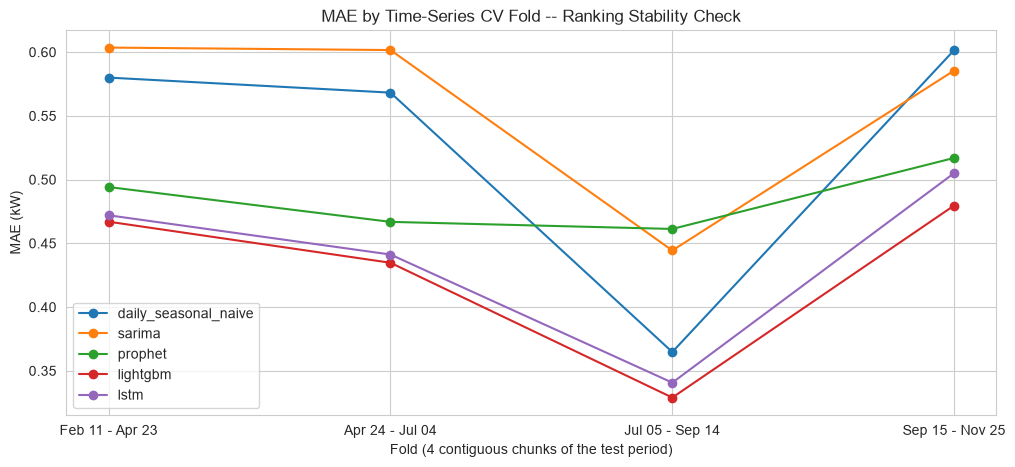

method,daily_seasonal_naive,lightgbm,lstm,prophet,sarima
fold_label,,,,,
Feb 11 - Apr 23,0.580005,0.466948,0.471987,0.494142,0.603556
Apr 24 - Jul 04,0.568220,0.434736,0.441208,0.466825,0.601612
Jul 05 - Sep 14,0.364714,0.328968,0.340677,0.461269,0.444372
Sep 15 - Nov 25,0.601559,0.479644,0.505029,0.516972,0.585536


In [6]:
N_FOLDS = 4
fold_of_origin = assign_cv_folds(canonical_origins, n_folds=N_FOLDS)

fold_df = fold_of_origin.rename_axis("origin").reset_index()
fold_labels = (
    fold_df.groupby("fold")["origin"]
    .agg(lambda s: f"{s.min().strftime('%b %d')} - {s.max().strftime('%b %d')}")
    .to_dict()
)

cv_results = canonical_results.copy()
cv_results["fold"] = cv_results["origin"].map(fold_of_origin)
cv_results = cv_results.dropna(subset=["fold"])

cv_metrics = (
    cv_results.groupby(["method", "fold"])
    .apply(lambda d: pd.Series(compute_metrics(d)), include_groups=False)
    .reset_index()
)
cv_metrics["fold_label"] = cv_metrics["fold"].map(fold_labels)

fig, ax = plt.subplots()
for name in CANONICAL_METHODS:
    subset = cv_metrics[cv_metrics["method"] == name].sort_values("fold")
    ax.plot(subset["fold_label"], subset["MAE"], marker="o", label=name)
ax.set_xlabel(f"Fold ({N_FOLDS} contiguous chunks of the test period)")
ax.set_ylabel("MAE (kW)")
ax.set_title("MAE by Time-Series CV Fold -- Ranking Stability Check")
ax.legend()
plt.show()

cv_metrics.pivot(index="fold_label", columns="method", values="MAE").loc[
    [fold_labels[f] for f in range(N_FOLDS)]
]

## Diebold-Mariano tests -- is each gap statistically meaningful?

Pairwise DM tests on mean absolute error per origin (averaged across the 24
horizon steps), tested only on origins both methods in a pair actually
cover -- see `src/evaluation/comparison.py` for why an inner join matters
here (LightGBM/LSTM drop origins near data gaps that SARIMA/Prophet don't).
`h=1`: origins are spaced exactly 24h apart with a 24h horizon, so forecast
windows never overlap and no autocovariance correction is needed.

In [7]:
dm_table = pairwise_dm_tests(canonical_results, CANONICAL_METHODS, loss="absolute", h=1)
dm_table["significant_0.05"] = dm_table["p_value"] < 0.05
dm_table.sort_values("p_value")

,method_a,method_b,mean_loss_diff,dm_statistic,p_value,n_origins,significant_0.05
2,daily_seasonal_naive,lightgbm,0.100287,9.021306,0.000000e+00,258,True
3,daily_seasonal_naive,lstm,0.093449,9.244131,0.000000e+00,271,True
7,prophet,lightgbm,0.056661,9.624976,0.000000e+00,258,True
6,sarima,lstm,0.122574,8.731862,2.220446e-16,271,True
5,sarima,lightgbm,0.133591,8.590304,8.881784e-16,258,True
8,prophet,lstm,0.047415,8.135143,1.509903e-14,271,True
4,sarima,prophet,0.080024,5.390633,1.488856e-07,282,True
1,daily_seasonal_naive,prophet,0.043105,3.674697,2.856694e-04,279,True
0,daily_seasonal_naive,sarima,-0.030847,-2.337225,2.013748e-02,279,True
9,lightgbm,lstm,-0.007755,-1.661667,9.780846e-02,256,False


## Error analysis by season

The test period (Feb 11 - Nov 25, 2010) covers all four seasons. Phase 2's
EDA found winter consumption roughly 2-3x summer's, with more volatility --
worth checking whether the Phase 5-8 ranking holds up in the season where
the forecasting problem is hardest, not just on average.

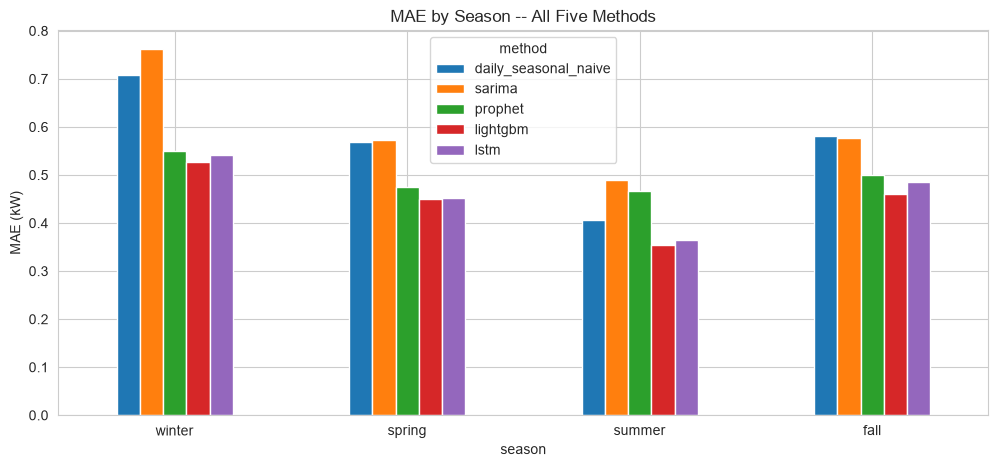

method,daily_seasonal_naive,lightgbm,lstm,prophet,sarima
season,,,,,
winter,0.708644,0.526278,0.541599,0.549382,0.763080
spring,0.568144,0.450598,0.452074,0.475304,0.573302
summer,0.405394,0.353275,0.364865,0.467292,0.488959
fall,0.581919,0.461188,0.484915,0.499532,0.576853


In [8]:
seasonal_results = add_season(canonical_results)

season_metrics = (
    seasonal_results.groupby(["method", "season"])
    .apply(lambda d: pd.Series(compute_metrics(d)), include_groups=False)
    .reset_index()
)

SEASON_ORDER = ["winter", "spring", "summer", "fall"]
season_mae = season_metrics.pivot(index="season", columns="method", values="MAE").loc[SEASON_ORDER]

fig, ax = plt.subplots()
season_mae[CANONICAL_METHODS].plot(kind="bar", ax=ax)
ax.set_ylabel("MAE (kW)")
ax.set_title("MAE by Season -- All Five Methods")
ax.legend(title="method")
plt.xticks(rotation=0)
plt.show()

season_mae

## Failure case analysis

The 10 largest absolute-error predictions per method, cross-referenced
against the Phase 1 long data gaps (Aug 17-22 and Sep 25-28, 2010, both
inside the test period) and the Phase 3 flagged anomaly dates.

In [9]:
KNOWN_GAP_RANGES = [
    (pd.Timestamp("2010-08-17"), pd.Timestamp("2010-08-22")),
    (pd.Timestamp("2010-09-25"), pd.Timestamp("2010-09-28")),
]


def flag_context(origin: pd.Timestamp) -> str:
    day = origin.normalize()
    if any(start <= day <= end for start, end in KNOWN_GAP_RANGES):
        return "near_data_gap"
    if day in FLAGGED_ANOMALY_DATES:
        return "flagged_anomaly"
    return ""


worst_by_method = []
for method in CANONICAL_METHODS:
    cases = worst_cases(canonical_results, method, n=10)
    cases["context"] = cases["origin"].map(flag_context)
    worst_by_method.append(cases)

worst_combined = pd.concat(worst_by_method, ignore_index=True)
flagged_share = (
    worst_combined.assign(is_flagged=worst_combined["context"] != "")
    .groupby("method")["is_flagged"]
    .mean()
)

print("Share of each method's top-10 worst cases landing on a known gap/anomaly day:")
print(flagged_share)
print()
worst_combined[["method", "origin", "horizon_step", "actual", "forecast", "loss", "context"]].sort_values(
    ["method", "loss"], ascending=[True, False]
)

Share of each method's top-10 worst cases landing on a known gap/anomaly day:
method
daily_seasonal_naive    0.2
lightgbm                0.2
lstm                    0.4
prophet                 0.4
sarima                  0.3
Name: is_flagged, dtype: float64



,method,origin,horizon_step,actual,forecast,loss,context
0,daily_seasonal_naive,2010-11-21,18,0.451133,5.626833,5.175700,
1,daily_seasonal_naive,2010-11-20,18,5.626833,1.018467,4.608367,
2,daily_seasonal_naive,2010-02-22,14,0.356700,4.638200,4.281500,
3,daily_seasonal_naive,2010-02-21,15,4.513500,0.348433,4.165067,flagged_anomaly
4,daily_seasonal_naive,2010-02-22,15,0.351667,4.513500,4.161833,
5,daily_seasonal_naive,2010-11-15,15,0.387300,4.156567,3.769267,
6,daily_seasonal_naive,2010-02-22,11,1.419467,5.090800,3.671333,
7,daily_seasonal_naive,2010-04-11,21,3.883133,0.356133,3.527000,
8,daily_seasonal_naive,2010-10-18,12,3.836433,0.313233,3.523200,flagged_anomaly
9,daily_seasonal_naive,2010-03-09,15,0.482467,3.969000,3.486533,


## Findings

- **Aggregate ranking confirms Phases 5-8, with LightGBM and LSTM well clear
  of the rest:** LightGBM (MAE 0.429) edges out LSTM (0.440), both well
  ahead of Prophet (0.485), the Phase 5 baseline (0.530), SARIMA (0.560),
  weekly seasonal naive (0.563), plain ARIMA (0.631), and flat persistence
  (0.664). One metric-level nuance worth flagging rather than over-reading:
  LSTM's MAPE (58.7%) is actually *better* than LightGBM's (62.0%), the only
  metric where the ranking flips. Given this project's standing finding
  (Phase 5) that MAPE/sMAPE are inflated and unreliable on this dataset
  (near-zero overnight consumption blows up percentage errors), MAE/RMSE
  remain the metrics to trust -- by those, LightGBM still leads.

- **Time-series CV: the top-2 ranking is rock-solid, but the middle of the
  pack reshuffles by season -- a genuinely non-obvious finding:** across all
  4 chronological folds, LightGBM is #1 and LSTM is #2 every single time,
  with no reversal. But Prophet, SARIMA, and the daily seasonal naive
  baseline swap order fold to fold. Most strikingly, in the Jul 5-Sep 14
  fold (summer), the **naive baseline (MAE 0.365) beats both SARIMA (0.444)
  and Prophet (0.461)** -- summer demand is low and stable (Phase 2's EDA
  already found this), so simple day-ago persistence is nearly unbeatable
  and the added complexity of SARIMA/Prophet doesn't pay off. The baseline
  falls back behind both in every other fold. The lesson: "beats the
  baseline" is not a fixed property of a model here -- it depends on the
  season being forecast.

- **Diebold-Mariano tests: every pairwise gap is statistically significant
  except one -- LightGBM vs. LSTM (p=0.098).** Every comparison involving
  the baseline, SARIMA, or Prophet against LightGBM/LSTM is significant at
  p<0.001 (several below floating-point precision). But despite LightGBM's
  numerically lower MAE, the gap between the two best models **cannot be
  distinguished from noise** at the conventional 5% level (n=256 shared
  origins). The honest conclusion: LightGBM is the practical pick, but
  "LightGBM is definitively better than LSTM" is not a claim this test
  supports -- a good example of why the aggregate MAE table alone shouldn't
  be read as a confident ranking between close competitors.

- **Error by season: SARIMA loses to the trivial baseline in 3 of 4
  seasons, not just "sometimes":** winter (0.763 vs. 0.709), spring (0.573
  vs. 0.568), and summer (0.489 vs. 0.405) all favor the naive baseline over
  SARIMA; only fall (0.577 vs. 0.582) narrowly favors SARIMA. This sharpens
  Phase 6's "mixed, not a clean win" verdict into something more concrete:
  SARIMA's aggregate RMSE edge over the baseline was fragile and mostly
  didn't survive a season-by-season MAE view. LightGBM and LSTM, by
  contrast, beat every other method in every season -- winter is hardest
  for everyone (highest MAE across the board, matching Phase 2's higher/more
  volatile winter consumption), summer is easiest for everyone.

- **Failure case analysis: all five methods miss the same real-world
  events, not idiosyncratic ones -- and LightGBM's engineered anomaly flag
  visibly helps it there specifically.** The worst-10 lists overlap heavily
  across methods: Nov 20 (a large evening spike every model underpredicts),
  Feb 21 and Oct 18 (both Phase 3 flagged-anomaly dates), Mar 8, Nov 4, and
  Jun 30 recur across multiple methods' top failures. The share of each
  method's worst-10 cases landing on an already-known flagged/gap day:
  LSTM and Prophet 40%, SARIMA 30%, LightGBM and the baseline 20%.
  LightGBM is the *only* model given the Phase 4 `is_flagged_anomaly`
  feature directly, and it shows up here as proportionally fewer worst-case
  failures on exactly those pre-identified days -- concrete evidence that
  feature paid for itself, not just an assumption. None of the top failures
  fall inside the actual missing-data gap windows (Aug 17-22, Sep 25-28),
  confirming those periods are correctly excluded from scoring rather than
  silently leaking NaN-driven errors into the metrics.

- **What this means going into Part B (horizon sensitivity):** LightGBM and
  LSTM are the two models worth carrying into the 1h/7d horizon experiments
  -- their lead is stable across time and season, even though the two can't
  be statistically separated from each other. SARIMA and Prophet's more
  fragile, season-dependent standing relative to even the naive baseline is
  itself a useful data point for Part B: does either recover any edge at a
  different horizon, or does the same instability persist?
